In [6]:
from google.colab import files
uploaded = files.upload()  # this opens a file picker — choose train.csv

import pandas as pd
df = pd.read_csv('train.csv')
df.head()



Saving train.csv to train (4).csv


In [7]:
#IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

In [8]:
#Load data

df = pd.read_csv('train.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
#Structure & data types
df.info()
#The row count, which columns have missing values (e.g. Age, Cabin, Embarked), and data types.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
#Statistical summary

df.describe()

#Observation: Comment on ranges — e.g. average age, fare skew (max fare much higher than mean = outliers), survival rate (mean of Survived).

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
#Missing values

df.isnull().sum()

#Observation: Cabin is mostly missing, Age ~20% missing, Embarked has just a couple missing.

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
#Categorical count of Sex
df['Sex'].value_counts()


,count
Sex,
male,577
female,314


In [19]:
#Categorical count of pclass
df['Pclass'].value_counts()


,count
Pclass,
3,491
1,216
2,184


In [20]:
#Categorical count of Embarked
df['Embarked'].value_counts()
#Observation: More males than females aboard; most passengers in 3rd class.

,count
Embarked,
S,644
C,168
Q,77


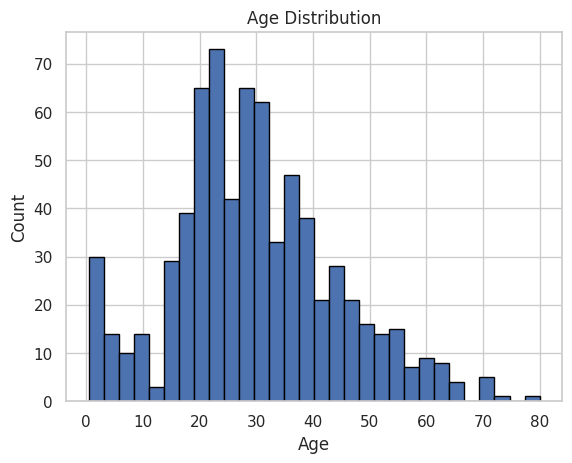

In [21]:
#Age distribution (histogram)

df['Age'].hist(bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Observation: Most passengers were young adults (20–40); a smaller bump of children.

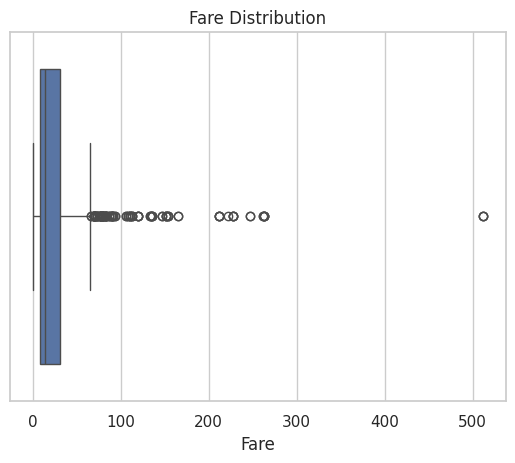

In [22]:
#Fare distribution (boxplot, check outliers)
sns.boxplot(x=df['Fare'])
plt.title('Fare Distribution')
plt.show()

#Observation: Heavily right-skewed with extreme outliers (very expensive first-class tickets).

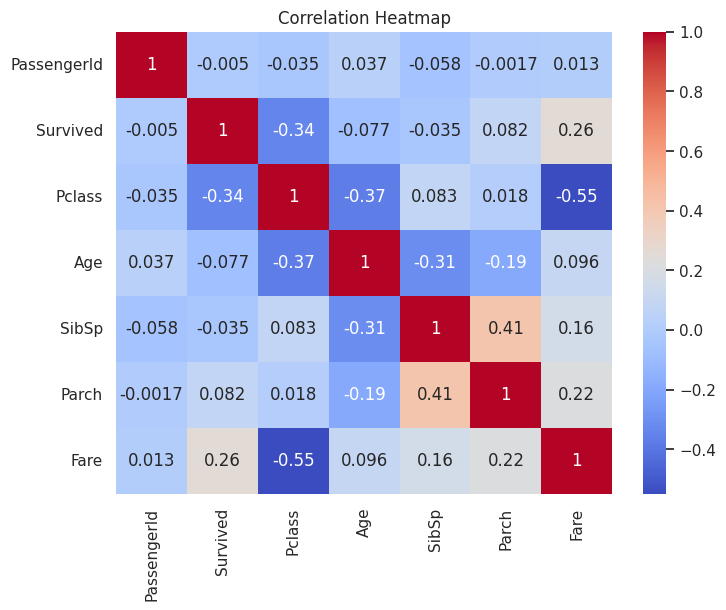

In [23]:
#Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
# Observation: Pclass negatively correlates with Fare and Survived; note strongest relationships.

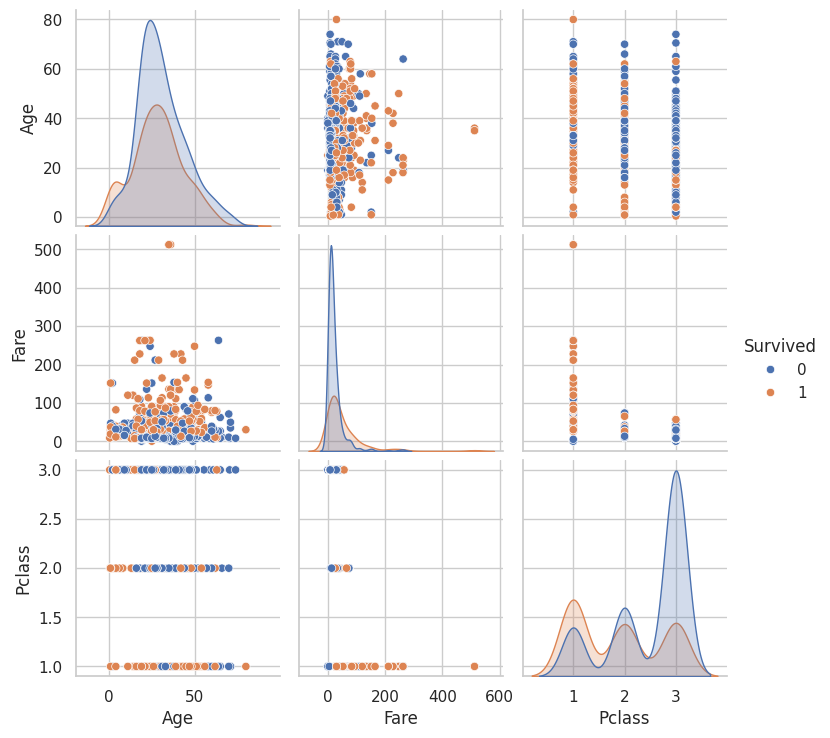

In [24]:
#Pairplot
sns.pairplot(df[['Age','Fare','Pclass','Survived']].dropna(), hue='Survived')
plt.show()

#Observation: Describe any visible separation between survivors/non-survivors by age or fare.

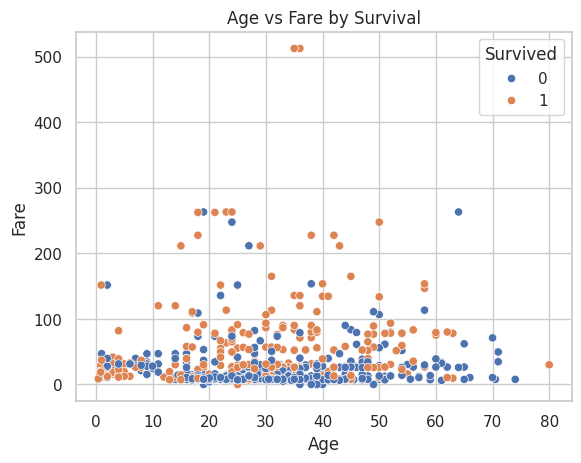

In [25]:
#Scatterplot: Age vs Fare colored by survival

sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Age vs Fare by Survival')
plt.show()